In [ ]:
#Conectando com Google Drive
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)


Mounted at /content/gdrive


In [ ]:
%cd /content/gdrive/MyDrive/Colab/Datasets

!ls

[Errno 2] No such file or directory: '/content/gdrive/MyDrive/Colab/Datasets'
/content
gdrive	sample_data


In [ ]:
#Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV, LearningCurveDisplay, ValidationCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
file_path = '/content/gdrive/MyDrive/Colab /Datasets/output.csv'

In [ ]:
df = pd.read_csv(file_path)

# Problema de Classificação de Imagens para identificação de Anemia





In [ ]:
print(df.head())

   Number Sex  %Red Pixel  %Green pixel  %Blue pixel    Hb Anaemic
0       1   M     43.2555       30.8421      25.9025   6.3     Yes
1       2   F     45.6033       28.1900      26.2067  13.5      No
2       3  F      45.0107       28.9677      26.0215  11.7      No
3       4   F     44.5398       28.9899      26.4703  13.5      No
4       5  M      43.2870       30.6972      26.0158  12.4      No


# 1. Checando a Base de Dados





In [ ]:
# Checando NaN dados
nan_data_by_column = df.isna().sum()
nan_total_data = df.isna().sum().sum()

print("NaN data by column:")
print(nan_data_by_column)
print("\nTotal NaN data in DataFrame:", nan_total_data)

NaN data by column:
Number          0
Sex             0
%Red Pixel      0
%Green pixel    0
%Blue pixel     0
Hb              0
Anaemic         0
dtype: int64

Total NaN data in DataFrame: 0


In [ ]:
# Checando por missing data
missing_data = df.isnull()

print("Missing data by column:")
missing_data

Missing data by column:


,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
99,False,False,False,False,False,False,False
100,False,False,False,False,False,False,False
101,False,False,False,False,False,False,False
102,False,False,False,False,False,False,False


# 2. Pré-Processamento dos Dados

In [ ]:
#Pré-Processamento dos dados

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder


In [ ]:
#Pré-Processando os Dados - Padronizando

# Iniciar StandardScaler
scaler_standard = StandardScaler()

# Aplicando StandardScaler às variáveis, corrigindo erro com reshape
df['%Red Pixel'] = scaler_standard.fit_transform(df['%Red Pixel'].values.reshape(-1, 1))
df['%Green pixel'] = scaler_standard.fit_transform(df['%Green pixel'].values.reshape(-1, 1))
df['%Blue pixel'] = scaler_standard.fit_transform(df['%Blue pixel'].values.reshape(-1, 1))
df['Hb'] = scaler_standard.fit_transform(df['Hb'].values.reshape(-1, 1))

# Vizualizando
scaler_standard

StandardScaler()

In [ ]:
#Pré-Processamento dos Dados - Ajustando dados, pois HB estava num range diferente

# Inicializando MinMaxScaler
scaler_minmax = MinMaxScaler()

# Aplicando MinMaxScaler às variáveis, corrigindo com reshape
df['%Red Pixel'] = scaler_minmax.fit_transform(df['%Red Pixel'].values.reshape(-1, 1))
df['%Green pixel'] = scaler_minmax.fit_transform(df['%Green pixel'].values.reshape(-1, 1))
df['%Blue pixel'] = scaler_minmax.fit_transform(df['%Blue pixel'].values.reshape(-1, 1))
df['Hb'] = scaler_minmax.fit_transform(df['Hb'].values.reshape(-1, 1))

# Vizualizando
scaler_minmax

MinMaxScaler()

In [ ]:
# Codificar variáveis ​​categóricas
label_encoder = LabelEncoder()

# Aplicando nas colunas e transformando em números
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['Anaemic'] = label_encoder.fit_transform(df['Anaemic'])

# Viewing
label_encoder

LabelEncoder()

In [ ]:
# Vizualizando
df.head()

,Number,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,1,2,0.281288,0.788871,0.617586,0.259259,1
1,2,0,0.429405,0.421940,0.647120,0.792593,0
2,3,1,0.392019,0.529539,0.629140,0.659259,0
3,4,0,0.362312,0.532610,0.672712,0.792593,0
4,5,3,0.283276,0.768823,0.628586,0.711111,0


In [ ]:
# Convertendo a coluna 'Anaemic' para tipo inteiro
df['Anaemic'] = df['Anaemic'].astype('int64')
df.dtypes

,0
Number,int64
Sex,int64
%Red Pixel,float64
%Green pixel,float64
%Blue pixel,float64
Hb,float64
Anaemic,int64


In [ ]:
#Pré-Processamento dos dados - Excluindo Colunas
df = df.drop(columns = 'Number')

In [ ]:
#Pré-Processamento - Excluindo Caracteres especiais
df.rename(columns = {'%Red Pixel':'Red_pixel',

                      '%Green pixel': 'Green_pixel',

                      '%Blue pixel': 'Blue_pixel'}, inplace = True)

In [ ]:
#Visualizando o novo DataFrame
df.head(10)

,Sex,Red_pixel,Green_pixel,Blue_pixel,Hb,Anaemic
0,2,0.281288,0.788871,0.617586,0.259259,1
1,0,0.429405,0.421940,0.647120,0.792593,0
2,1,0.392019,0.529539,0.629140,0.659259,0
3,0,0.362312,0.532610,0.672712,0.792593,0
4,3,0.283276,0.768823,0.628586,0.711111,0
5,2,0.397615,0.390741,0.717935,0.992593,0
6,0,0.274361,0.694886,0.694187,0.429630,1
7,1,0.303672,0.549213,0.751303,0.555556,0
8,0,0.394013,0.556974,0.606839,0.755556,0
9,0,0.486878,0.316542,0.632635,0.511111,1


In [ ]:
df.dtypes

,0
Sex,int64
Red_pixel,float64
Green_pixel,float64
Blue_pixel,float64
Hb,float64
Anaemic,int64


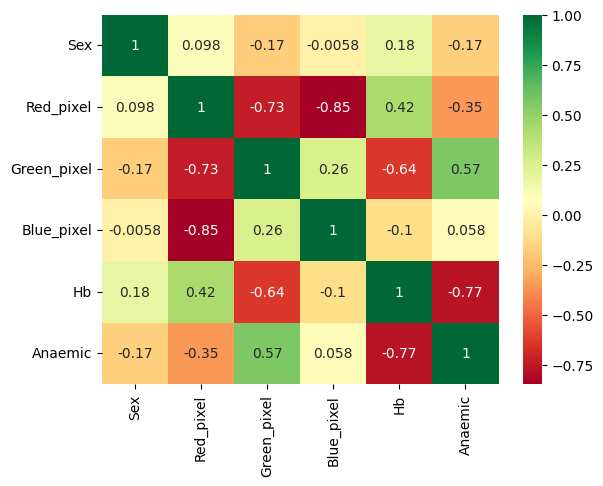

In [ ]:
#Construindo a correlação de pixels em rgb com HB
numerical_cols = ['Sex', 'Red_pixel', 'Green_pixel', 'Blue_pixel', 'Hb', 'Anaemic']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, cmap = 'RdYlGn', annot = True)

plt.show()

In [ ]:
#Pré-Processamento - Excluindo sex por não ser informação das imagens.
df = df.drop(columns = 'Sex' )


In [ ]:
df.head(5)

,Red_pixel,Green_pixel,Blue_pixel,Hb,Anaemic
0,0.281288,0.788871,0.617586,0.259259,1
1,0.429405,0.421940,0.647120,0.792593,0
2,0.392019,0.529539,0.629140,0.659259,0
3,0.362312,0.532610,0.672712,0.792593,0
4,0.283276,0.768823,0.628586,0.711111,0


# 3. Implementando o Modelo 1 - Machine Learning - MLPRegressor



In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [ ]:
#Definindo os conjuntos de treino e teste

X = df.drop(columns = ['Anaemic'])
y = df['Anaemic']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state=200)

# Visualizando linhas e colunas de conjunto de treinamento
print("Rows and columns of training data X_train:", X_train.shape)
print("Rows and columns of training data y_train:", y_train.shape)

Rows and columns of training data X_train: (93, 4)
Rows and columns of training data y_train: (93,)


In [ ]:
# Encontrando os melhores parâmetros do MLP e com o TimeSeriesSplit no cross validation

param_MLP = {
    'hidden_layer_sizes': [(30), (100), (10), (20), (10,30), (100,100)],
    'activation': ['relu', 'tanh', 'logistic','identity'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1]}

In [ ]:
# Melhores parâmetros
grid_search_mlp = GridSearchCV(
    MLPRegressor(random_state=1, max_iter=500),
    param_MLP,
    cv = TimeSeriesSplit(5),
    n_jobs=-1
    )

grid_search_mlp.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 751, in fit
    return self._fit(X, y, incremental=False)
  File "/usr/l

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=MLPRegressor(max_iter=500, random_state=1), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh', 'logistic', 'identity'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [30, 100, 10, 20, (10, 30),
                                                (100, 100)],
                         'learning_rate_init': [0.001, 0.01, 0.1],
                         'solver': ['adam', 'sgd']})

In [ ]:
print(f"Melhores parâmetros: {grid_search_mlp.best_params_}")

Melhores parâmetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (10, 30), 'learning_rate_init': 0.1, 'solver': 'adam'}


In [ ]:
# Aplicando os melhores parâmetros do MPL
mlp = MLPRegressor(
    activation='relu',
    alpha=0.001,
    hidden_layer_sizes=10,
    learning_rate_init=0.1,
    solver='adam',
    max_iter=1000,  # Número máximo de iterações
    random_state=42)

mlp.fit(X_train,y_train)

MLPRegressor(alpha=0.001, hidden_layer_sizes=10, learning_rate_init=0.1,
             max_iter=1000, random_state=42)

In [ ]:
# Fazendo a classificação
y_predmlpr= mlp.predict(X_test)


In [ ]:
X_test

,Red_pixel,Green_pixel,Blue_pixel,Hb
36,0.480178,0.418357,0.571499,0.792593
19,0.134988,0.944741,0.733342,0.525926
2,0.392019,0.529539,0.629140,0.659259
75,0.953536,0.166745,0.019611,0.866667
34,0.211722,0.732131,0.764449,0.807407
39,0.463573,0.355323,0.641285,0.837037
82,0.273592,0.581864,0.774682,0.562963
9,0.486878,0.316542,0.632635,0.511111
21,0.291824,0.643156,0.703615,0.711111
69,0.514977,0.464733,0.485403,0.414815


In [ ]:
y_predmlpr

array([ 0.03557976,  0.83058563,  0.14457472,  0.07170809,  0.0460823 ,
       -0.02194981,  0.36869255,  0.25196798,  0.13742974,  0.5194625 ,
        0.03986806])

In [ ]:
#Ajustando o vetor à classe binária
y_predmlp_ar = (y_predmlpr >= 0.5).astype(int)

print(y_predmlp_ar)

[0 1 0 0 0 0 0 0 0 1 0]


In [ ]:
accuracy_mlpr = accuracy_score(y_test, y_predmlp_ar)

In [ ]:
print(accuracy_mlpr)

0.8181818181818182


In [ ]:
#Predição do Conjunto de Treino
y_predtrainmlpr=mlp.predict(X_train)

In [ ]:
y_predmlp_train_ar= (y_predtrainmlpr >= 0.5).astype(int)

print(y_predmlp_train_ar)

[0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1 0]


In [ ]:
accuracy_mlp_trainr = accuracy_score(y_train, y_predmlp_train_ar)
print(accuracy_mlp_trainr)

0.967741935483871


 3.1 Discussão Sobre o Modelo de Rede Neural - MLPRegressor

 Rede Neural escolhida - MLP com parâmetros ajustados usando o GRIDsearch para obter os melhores parâmetros para melhor performance, realizado teste com 10 camadas e o conjunto de teste de 10%, foram obtidos os resultados:

 Acurácia Conjunto teste: 81,81%
 Acurácia Conjunto treino: 96,77%



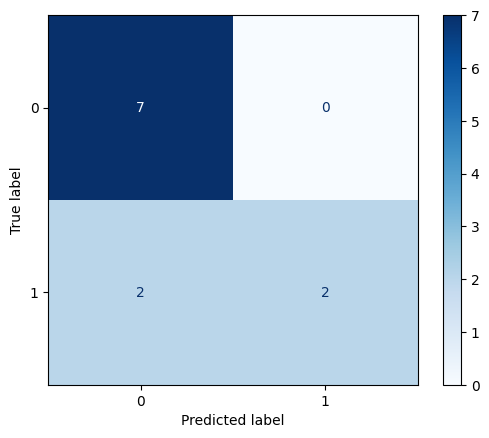

In [ ]:
#Criando a matriz confusão para avaliar o modelo testado
conf_matrix = confusion_matrix(y_test, y_predmlp_ar)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap="Blues")

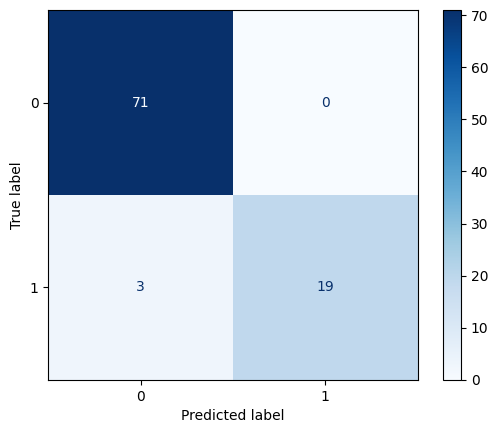

In [ ]:
#Criando a matriz confusão para avaliar o modelo treinado
conf_matrix = confusion_matrix(y_train, y_predmlp_train_ar)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap="Blues")

3.2 Considerações sobre o Modelo MLPRegressor com a Matriz Confusão

Ao se observar a matriz confusão do conjunto de teste para o problema de predição de Anemia, se verifica que grande parte da classificação que foi correta é no primeiro quadrante (0,0), o que quer dizer que são pacientes que não têm anemia e têm a etiqueta de não. No conjunto de dados do quadrante (1,1) que são pacientes que têm anemia e têm o rótulo correto nos dados, ele classificou um número menor e classificou 0, os pacientes que não teriam anemia na etiqueta, mas seriam classificados como se tivessem anemia (falso positivo) e houveram dados que foram falsos negativos, seriam pacientes que teriam a doença, mas o algoritmo classificou como falso negativo.

Essa observação ilustra que apesar do erro do algoritmo no conjunto teste, este, possui uma perda considerável de performance, por causa do algoritmo apresentar um número de classificação de falsos negativos, logo o paciente que teria a doença poderia seria penalizado se o algoritmo for usado para tomada de decisão. Contudo, também é de se considerar que o volume de dados é pequena para a natureza da complexidade do problema. Então, pode adicionar esse problema de performance à baixa quantidade de teste. Também se pode observar através da matriz confusão do conjunto que foi treinado, a acurácia foi mais que o conjunto testado, porém ainda continua errando no conjunto de pacientes falso negativos.

# 4. Implementando o Modelo 2 - Machine Learning - MLP

In [ ]:
#Importando as Bibliotecas
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
#Definindo o Conjunto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
# Criando o modelo MLP
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Camada oculta com 64 neurônios
    Dense(32, activation='relu'),  # Outra camada oculta com 32 neurônios
    Dense(1, activation='sigmoid')  # Camada de saída para classificação binária
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilar o modelo MLP
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Treinando o modelo MLP
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.2487 - loss: 0.7916 - val_accuracy: 0.2727 - val_loss: 0.7480
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2369 - loss: 0.7593 - val_accuracy: 0.2727 - val_loss: 0.7164
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2643 - loss: 0.7202 - val_accuracy: 0.2727 - val_loss: 0.6881
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4319 - loss: 0.6894 - val_accuracy: 1.0000 - val_loss: 0.6640
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8535 - loss: 0.6684 - val_accuracy: 0.9091 - val_loss: 0.6423
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8344 - loss: 0.6457 - val_accuracy: 0.8182 - val_loss: 0.6229
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7870 - loss: 0.6257 - val_accuracy: 0.7273 - val_loss: 0.6065
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7450 - loss: 0.6114 - val_accuracy: 0.7273 - val_loss: 0.5933

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8182 - loss: 0.4456
Loss: 0.44559726119041443, Accuracy: 0.8181818127632141


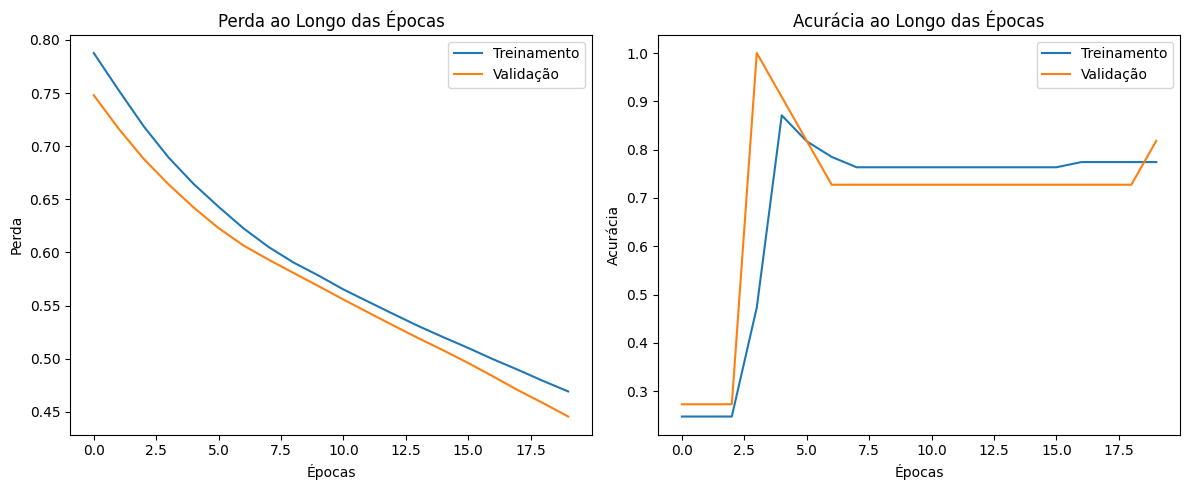

In [ ]:
# Criar subplots lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))  # 1 linha, 2 colunas

# Gráfico da Perda
ax[0].plot(history.history['loss'], label='Treinamento')
ax[0].plot(history.history['val_loss'], label='Validação')
ax[0].set_title('Perda ao Longo das Épocas')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Perda')
ax[0].legend()

# Gráfico da Acurácia
ax[1].plot(history.history['accuracy'], label='Treinamento')
ax[1].plot(history.history['val_accuracy'], label='Validação')
ax[1].set_title('Acurácia ao Longo das Épocas')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Acurácia')
ax[1].legend()

# Ajustar espaçamento
plt.tight_layout()
plt.show()

4.1 Comentários sobre o Modelo 2 de Machine Learning

A performance do MLP foi praticamente igual ao MLPRegressor, talvez por conta do ajuste da performance e do problema ter a classe de anemia convertida ao número binário.
Além disso, é verificado aqui nos gráficos sobre a performance do MLP que com o passar das épocas houve uma diminuição da perda para os dois conjuntos, Treinamento e Validação que é o mesmo que teste. Além disso, para o MLP, o conjunto de validação teve uma acurácia maior que o conjunto de treinamento, sendo interessante que apesar do número de dados reduzido para o teste (apenas 10% foi usado), esse Modelo apresentou uma melhor performance nesse aspecto, porém ao se avaliar a função perda, foi de 44%, o que é bastante elevado para um problema de diagnóstico, apesar de ter uma acurácia de 81%.